# Effect of cocktail composition on TDCR detection efficiency

Studies two scenarios for **Ultima Gold** scintillator:

1. **Aqueous water fraction** — fAq from 0 to 0.5 (pure water dilution)
2. **HCl concentration** — at fixed fAq = 0.1, [HCl] from 0 to 5 mol L⁻¹

### Technical note on the quenching model
TDCRPy's default quenching path uses **pre-computed interpolation tables** for
electron energies above *Einterp_e* = 1.5 keV.  Those tables are
Z/A-independent by construction.  To capture the true composition effect,
this notebook calls the **direct Birks integral** (`E_quench_e`) for every
energy bin by passing a large interpolation threshold (`Et_override`).
After each composition change `importlib.reload` refreshes the module-level
Z, A, rho so the correct stopping power is used.

Nuclides: **H-3** (18.6 keV pure β⁻) and **Sr-90** (546 keV pure β⁻)

In [1]:
pip install TDCRPy==2.20.12

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import tdcrpy as td
import tdcrpy.TDCR_model_lib as tl
from importlib.metadata import version
warnings.filterwarnings('ignore')
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.12


## ⚙️ Configuration

In [3]:
# ── Parameters ──────────────────────────────────────────────────────────────
L        = 5.0      # free parameter (photons keV⁻¹)
kB       = 1.0e-5   # Birks constant (cm keV⁻¹)
V        = 10       # volume (mL)
ne       = 500      # quenching integral bins (lower = faster)

# Force direct Birks integral for all energies (bypasses Z/A-independent tables)
# Any value above the max beta energy works; 100 keV covers H-3 and Sr-90
Et_override = 100 * 1e3   # eV — interpolation threshold override

NUCLIDES = ['H-3', 'Sr-90']
COLORS   = ['#1f77b4', '#e74c3c']

# Aqueous fraction scan
fAq_vec  = np.linspace(0.0, 0.50, 11)

# HCl concentration scan at fixed fAq
fAq_HCl  = 0.10
HCl_vec  = np.linspace(0.0, 5.0, 11)

print(f'L={L} photons/keV  kB={kB} cm/keV  ne={ne}  Et_override={Et_override/1e3:.0f} keV')

L=5.0 photons/keV  kB=1e-05 cm/keV  ne=500  Et_override=100 keV


## Helper: compute efficiency from quenched spectrum

For each composition the function:
1. Updates the cocktail config and reloads the module (refreshes Z, A, rho)
2. Reads the beta spectrum from `readBetaSpectra`
3. Computes quenched energy using the **direct Birks integral** (no table lookup)
4. Returns eff_S, eff_D, eff_T from the TDCR detection formula

In [4]:
def compute_efficiency(rad, L, kB, ne, Et_ov, cocktail='Ultima Gold',
                       fAq=0.0, solvantType='Water', solvantConc=0.0):
    """Return (eff_S, eff_D, eff_T, Z, A, rho) for the given composition."""
    global tl

    # 1. Update config and reload module so Z/A/rho are current
    tl.modifyLScocktail(cocktail, fAq, solvantType, solvantConc)
    tl = importlib.reload(tl)

    mu  = np.mean(tl.effQuantic)
    Z   = tl.Z
    A   = tl.A
    rho = tl.RHO

    # 2. Read deposited-energy spectrum
    e_spec, p_spec = tl.readBetaSpectra(rad)
    e_spec = np.asarray(e_spec)  # keV
    p_spec = np.asarray(p_spec)

    # 3. Quenched energy — direct Birks integral (Et_ov forces this for all energies)
    em = np.array([
        tl.Em_e(ei * 1e3, ei * 1e3, kB * 1e3, ne, Et=Et_ov) * 1e-3
        for ei in e_spec
    ])

    # 4. Detection probability per energy bin (symmetric TDCR, 3 PMTs)
    x   = L * mu * em / 3
    pe  = 1.0 - np.exp(-x)

    eff_S = float(np.dot(p_spec, 1.0 - (1.0 - pe)**3))
    eff_T = float(np.dot(p_spec, pe**3))
    eff_D = float(np.dot(p_spec, 3*pe**2 - 2*pe**3))

    return eff_S, eff_D, eff_T, Z, A, rho

print('Helper defined.')

Helper defined.


## Part 1 — Efficiency vs aqueous water fraction

In [5]:
res1 = {rad: {'S':[], 'D':[], 'T':[], 'Z':[], 'A':[], 'rho':[]} for rad in NUCLIDES}

for fAq in fAq_vec:
    for rad in NUCLIDES:
        s, d, t, Z, A, rho = compute_efficiency(
            rad, L, kB, ne, Et_override,
            fAq=fAq, solvantType='Water', solvantConc=0.0)
        res1[rad]['S'].append(s)
        res1[rad]['D'].append(d)
        res1[rad]['T'].append(t)
        res1[rad]['Z'].append(Z)
        res1[rad]['A'].append(A)
        res1[rad]['rho'].append(rho)
    print(f'  fAq={fAq:.2f}  Z={Z:.4f}  A={A:.4f}  rho={rho:.4f}'
          f'  H3 eff_D={res1["H-3"]["D"][-1]:.5f}  Sr90 eff_D={res1["Sr-90"]["D"][-1]:.5f}')

# Restore defaults
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)
print('\nDone.')

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  fAq=0.00  Z=3.2516  A=5.9449  rho=0.9800  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.05 (Type: Water, 0.0 mol/L)
	Density = 0.9808942233452657 g/cm3
	Z = 3.2556, A = 5.9479
	Atomic fraction: H=0.5748, C=0.3710, N=0.0009, O=0.0500
	                 P=0.0024, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.05 (Type: Water, 0.0 mol/L)
	Density = 0.9808942233452657 g/cm3
	Z = 3.2556, A = 5.9479
	Atomic fraction: H=0.5748, C=0.3710, N=0.0009, O=0.0500
	                 P=0.0024, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  fAq=0.05  Z=3.2556  A=5.9479  rho=0.9809  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: Water, 0.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2597, A = 5.9509
	Atomic fraction: H=0.5796, C=0.3517, N=0.0008, O=0.0648
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 

...

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.45 (Type: Water, 0.0 mol/L)
	Density = 0.9881071908364562 g/cm3
	Z = 3.2882, A = 5.9720
	Atomic fraction: H=0.6132, C=0.2157, N=0.0005, O=0.1687
	                 P=0.0014, S=0.0003, Na=0.0003, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  fAq=0.45  Z=3.2882  A=5.9720  rho=0.9881  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.5 (Type: Water, 0.0 mol/L)
	Density = 0.9890162774239207 g/cm3
	Z = 3.2923, A = 5.9750
	Atomic fraction: H=0.6181, C=0.1962, N=0.0005, O=0.1836
	                 P=0.0013, S=0.0002, Na=0.0002, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.5 (Type: Water, 0.0 mol/L)
	Density = 0.9890162774239207 g/cm3
	Z = 3.2923, A = 5.9750
	Atomic fraction: H=0.6181, C=0.1962, N=0.0005, O=0.1836
	                 P=0.0013, S=0.0002, Na=0.0002, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  fAq=0.50  Z=3.2923  A=5.9750  rho=0.9890  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Done.


In [ ]:
Z_arr   = np.array(res1['H-3']['Z'])
A_arr   = np.array(res1['H-3']['A'])
rho_arr = np.array(res1['H-3']['rho'])
x_lbl   = 'Aqueous fraction fAq (%)'
x_data  = fAq_vec * 100
title   = f'Ultima Gold + pure water  |  L={L} photons/keV  kB={kB} cm/keV'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(title, fontsize=11)

for row, (rad, col) in enumerate(zip(NUCLIDES, COLORS)):
    d_arr = np.array(res1[rad]['D'])
    d0    = d_arr[0]   # reference: pure cocktail (fAq=0)
    resid = (d_arr - d0) * 1e6   # absolute residual in ppm

    # Col 0: eff_D
    ax = axes[row, 0]
    ax.plot(x_data, d_arr, 'o-', color=col)
    ax.set_xlabel(x_lbl, fontsize=10)
    ax.set_ylabel('eff_D', fontsize=10)
    ax.set_title(f'{rad} — double coincidence efficiency', fontsize=10)
    ax.grid(alpha=0.3)

    # Col 1: residual (ppm)
    ax = axes[row, 1]
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.plot(x_data, resid, 's-', color=col)
    ax.set_xlabel(x_lbl, fontsize=10)
    ax.set_ylabel('Δeff_D (ppm vs fAq=0)', fontsize=10)
    ax.set_title(f'{rad} — residual', fontsize=10)
    ax.grid(alpha=0.3)

# Col 2: Z/A (shared)
for row in range(2):
    ax = axes[row, 2]
    ax.plot(x_data, Z_arr / A_arr, 's-', color='purple')
    ax.set_xlabel(x_lbl, fontsize=10)
    ax.set_ylabel('Effective Z/A', fontsize=10)
    ax.set_title('Scintillator Z/A', fontsize=10)
    ax.grid(alpha=0.3)

# Col 3: density (shared)
for row in range(2):
    ax = axes[row, 3]
    ax.plot(x_data, rho_arr, '^-', color='brown')
    ax.set_xlabel(x_lbl, fontsize=10)
    ax.set_ylabel('Density (g/cm³)', fontsize=10)
    ax.set_title('Scintillator density', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cocktail_fAq_water_scan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## Part 2 — Efficiency vs HCl concentration at fAq = 0.1

In [7]:
res2 = {rad: {'S':[], 'D':[], 'T':[], 'Z':[], 'A':[], 'rho':[]} for rad in NUCLIDES}

for conc in HCl_vec:
    for rad in NUCLIDES:
        s, d, t, Z, A, rho = compute_efficiency(
            rad, L, kB, ne, Et_override,
            fAq=fAq_HCl, solvantType='HCl', solvantConc=float(conc))
        res2[rad]['S'].append(s)
        res2[rad]['D'].append(d)
        res2[rad]['T'].append(t)
        res2[rad]['Z'].append(Z)
        res2[rad]['A'].append(A)
        res2[rad]['rho'].append(rho)
    print(f'  [HCl]={conc:.1f} mol/L  Z={Z:.4f}  A={A:.4f}  Cl={tl.pCl:.5f}'
          f'  H3 eff_D={res2["H-3"]["D"][-1]:.5f}  Sr90 eff_D={res2["Sr-90"]["D"][-1]:.5f}')

# Restore defaults
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)
print('\nDone.')

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 0.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2597, A = 5.9509
	Atomic fraction: H=0.5796, C=0.3517, N=0.0008, O=0.0648
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 0.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2597, A = 5.9509
	Atomic fraction: H=0.5796, C=0.3517, N=0.0008, O=0.0648
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  [HCl]=0.0 mol/L  Z=3.2597  A=5.9509  Cl=0.00000  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 0.5 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2629, A = 5.9581
	Atomic fraction: H=0.5793, C=0.3521, N=0.0008, O=0.0643
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0003
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 0.5 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2629, A = 5.9581
	Atomic fraction: H=0.5793, C=0.3521, N=0.0008, O=0.0643
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0003
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  [HCl]=0.5 mol/L  Z=3.2629  A=5.9581  Cl=0.00030  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 1.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2662, A = 5.9652
	Atomic fraction: H=0.5791, C=0.3525, N=0.0008, O=0.0638
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0006
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 

...

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 4.5 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2875, A = 6.0121
	Atomic fraction: H=0.5778, C=0.3553, N=0.0008, O=0.0604
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0025
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  [HCl]=4.5 mol/L  Z=3.2875  A=6.0121  Cl=0.00252  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 5.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2904, A = 6.0185
	Atomic fraction: H=0.5776, C=0.3556, N=0.0008, O=0.0599
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0028
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 5.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2904, A = 6.0185
	Atomic fraction: H=0.5776, C=0.3556, N=0.0008, O=0.0599
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0028
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


  [HCl]=5.0 mol/L  Z=3.2904  A=6.0185  Cl=0.00279  H3 eff_D=0.65212  Sr90 eff_D=0.98635
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Done.


In [ ]:
Z_arr2   = np.array(res2['H-3']['Z'])
A_arr2   = np.array(res2['H-3']['A'])
rho_arr2 = np.array(res2['H-3']['rho'])
x_lbl2   = '[HCl] (mol L⁻¹)'
title2   = f'Ultima Gold + HCl aqueous (fAq={fAq_HCl})  |  L={L} photons/keV  kB={kB} cm/keV'

fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8))
fig2.suptitle(title2, fontsize=11)

for row, (rad, col) in enumerate(zip(NUCLIDES, COLORS)):
    d_arr2 = np.array(res2[rad]['D'])
    d0_2   = d_arr2[0]   # reference: [HCl]=0
    resid2 = (d_arr2 - d0_2) * 1e6   # ppm

    # Col 0: eff_D
    ax = axes2[row, 0]
    ax.plot(HCl_vec, d_arr2, 'o-', color=col)
    ax.set_xlabel(x_lbl2, fontsize=10)
    ax.set_ylabel('eff_D', fontsize=10)
    ax.set_title(f'{rad} — double coincidence efficiency', fontsize=10)
    ax.grid(alpha=0.3)

    # Col 1: residual
    ax = axes2[row, 1]
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.plot(HCl_vec, resid2, 's-', color=col)
    ax.set_xlabel(x_lbl2, fontsize=10)
    ax.set_ylabel('Δeff_D (ppm vs [HCl]=0)', fontsize=10)
    ax.set_title(f'{rad} — residual', fontsize=10)
    ax.grid(alpha=0.3)

# Col 2: Z/A
for row in range(2):
    ax = axes2[row, 2]
    ax.plot(HCl_vec, Z_arr2 / A_arr2, 's-', color='purple')
    ax.set_xlabel(x_lbl2, fontsize=10)
    ax.set_ylabel('Effective Z/A', fontsize=10)
    ax.set_title('Scintillator Z/A', fontsize=10)
    ax.grid(alpha=0.3)

# Col 3: density
for row in range(2):
    ax = axes2[row, 3]
    ax.plot(HCl_vec, rho_arr2, '^-', color='brown')
    ax.set_xlabel(x_lbl2, fontsize=10)
    ax.set_ylabel('Density (g/cm³)', fontsize=10)
    ax.set_title('Scintillator density', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cocktail_HCl_scan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## Summary table

In [9]:
print('── Part 1: water fraction scan ──────────────────────────────────────')
print(f'{"fAq":>6}  {"Z":>7}  {"A":>7}  {"rho":>6}  {"H-3 eff_D":>10}  {"Sr-90 eff_D":>12}')
print('─' * 65)
for i, fAq in enumerate(fAq_vec):
    Z   = res1['H-3']['Z'][i]
    A   = res1['H-3']['A'][i]
    rho = res1['H-3']['rho'][i]
    dH  = res1['H-3']['D'][i]
    dS  = res1['Sr-90']['D'][i]
    print(f'{fAq:6.2f}  {Z:7.4f}  {A:7.4f}  {rho:6.4f}  {dH:10.5f}  {dS:12.5f}')

print()
print('── Part 2: HCl concentration scan (fAq=0.1) ─────────────────────────')
print(f'{"[HCl]":>7}  {"Z":>7}  {"A":>7}  {"rho":>6}  {"H-3 eff_D":>10}  {"Sr-90 eff_D":>12}')
print('─' * 67)
for i, conc in enumerate(HCl_vec):
    Z   = res2['H-3']['Z'][i]
    A   = res2['H-3']['A'][i]
    rho = res2['H-3']['rho'][i]
    dH  = res2['H-3']['D'][i]
    dS  = res2['Sr-90']['D'][i]
    print(f'{conc:7.1f}  {Z:7.4f}  {A:7.4f}  {rho:6.4f}  {dH:10.5f}  {dS:12.5f}')

── Part 1: water fraction scan ──────────────────────────────────────
   fAq        Z        A     rho   H-3 eff_D   Sr-90 eff_D
─────────────────────────────────────────────────────────────────
  0.00   3.2516   5.9449  0.9800     0.65212       0.98635
  0.05   3.2556   5.9479  0.9809     0.65212       0.98635
  0.10   3.2597   5.9509  0.9818     0.65212       0.98635
  0.15   3.2637   5.9539  0.9827     0.65212       0.98635
  0.20   3.2678   5.9569  0.9836     0.65212       0.98635
  0.25   3.2719   5.9599  0.9845     0.65212       0.98635
  0.30   3.2760   5.9630  0.9854     0.65212       0.98635
  0.35   3.2801   5.9660  0.9863     0.65212       0.98635
  0.40   3.2841   5.9690  0.9872     0.65212       0.98635
  0.45   3.2882   5.9720  0.9881     0.65212       0.98635
  0.50   3.2923   5.9750  0.9890     0.65212       0.98635

── Part 2: HCl concentration scan (fAq=0.1) ─────────────────────────
  [HCl]        Z        A     rho   H-3 eff_D   Sr-90 eff_D
─────────────────────────

## Discussion — Why is the efficiency flat?

The detection efficiency is **insensitive to aqueous fraction or HCl concentration**
within the Ultima Gold + water/HCl system.

**Physical reason:** quenching depends on Z/A through the Bethe stopping-power
formula (dE/dx ∝ ρ·Z/A).  In this cocktail family all elements have similar Z/A:

| Element | Z | A | Z/A |
|---------|---|---|-----|
| H | 1 | 1.008 | 0.99 |
| C | 6 | 12.011 | 0.50 |
| O | 8 | 15.999 | 0.50 |
| Cl | 17 | 35.453 | **0.48** |

Adding water replaces C-rich cocktail with H+O (Z/A ≈ 0.55 → 0.56, Δ < 1%).
Adding HCl introduces Cl (Z/A = 0.48) which lowers Z/A by at most 0.3%.
The resulting stopping-power change is too small to measurably affect quenching.

**What matters more?** Comparing *fundamentally different* cocktails
(organic vs. aqueous), or scanning the Birks constant kB, produces much
larger efficiency changes.  The next section shows this.

## Part 3 — Broader context: stopping power and cocktail type

Compares the electron stopping power and efficiency for three representative media:
- **Ultima Gold** (pure, C-rich organic)
- **Ultima Gold + 50% water**
- **Water** (purely aqueous, H+O dominated)

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.5 (Type: Water, 0.0 mol/L)
	Density = 0.9890162774239207 g/cm3
	Z = 3.2923, A = 5.9750
	Atomic fraction: H=0.6181, C=0.1962, N=0.0005, O=0.1836
	                 P=0.0013, S=0.0002, Na=0.0002, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 1.0 (Type: Water, 0.0 mol/L)
	Density = 0.9982 g/cm3
	Z = 3.3335, A = 6.0054
	Atomic fraction: H=0.6666, C=0.0000, N=0.0000, O=0.3334
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Ultima Gold                  Z=3.2516 A=5.9449 rho=0.9800 eff_D=0.65212  eff_T=0.40009
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.5 (Type: Water, 0.0 mol/L)
	Density = 0.9890162774239207 g/cm3
	Z = 3.2923, A = 5.9750
	Atomic fraction: H=0.6181, C=0.1962, N=0.0005, O=0.1836
	                 P=0.0013, S=0.0002, Na=0.0002, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time =

Ultima Gold + 50% H2O        Z=3.2923 A=5.9750 rho=0.9890 eff_D=0.65212  eff_T=0.40009
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 1.0 (Type: Water, 0.0 mol/L)
	Density = 0.9982 g/cm3
	Z = 3.3335, A = 6.0054
	Atomic fraction: H=0.6666, C=0.0000, N=0.0000, O=0.3334
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Water                        Z=3.3335 A=6.0054 rho=0.9982 eff_D=0.65212  eff_T=0.40009


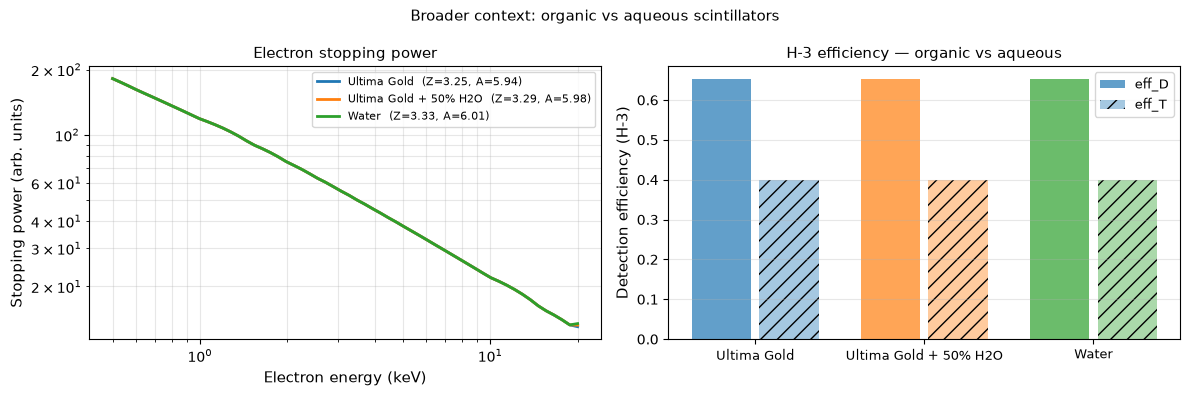

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Figure saved.


In [10]:
import importlib
import tdcrpy.TDCR_model_lib as tl

scenarios = [
    ('Ultima Gold',          0.0, 'Water', 0.0,  '#1f77b4'),
    ('Ultima Gold + 50% H2O', 0.5, 'Water', 0.0, '#ff7f0e'),
    ('Water',                1.0, 'Water', 0.0,  '#2ca02c'),
]

# ── Stopping power curves ────────────────────────────────────────────────────
e_keV = np.logspace(np.log10(0.5), np.log10(20), 60)  # 0.5 – 20 keV

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle('Broader context: organic vs aqueous scintillators', fontsize=11)

ax = axes3[0]
for label, fAq, sType, sConc, col in scenarios:
    tl.modifyLScocktail('Ultima Gold', fAq, sType, sConc)
    tl = importlib.reload(tl)
    sp = [tl.stoppingpower(e * 1e3) for e in e_keV]   # eV input, eV/nm output
    ax.loglog(e_keV, sp, '-', color=col, lw=2,
              label=f'{label}  (Z={tl.Z:.2f}, A={tl.A:.2f})')

ax.set_xlabel('Electron energy (keV)', fontsize=11)
ax.set_ylabel('Stopping power (arb. units)', fontsize=11)
ax.set_title('Electron stopping power', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

# ── Efficiency vs scenario ───────────────────────────────────────────────────
ax = axes3[1]
scenarios_eff = {}
for label, fAq, sType, sConc, col in scenarios:
    s, d, t, Z, A, rho = compute_efficiency('H-3', L, kB, ne, Et_override,
                                             fAq=fAq, solvantType=sType, solvantConc=sConc)
    scenarios_eff[label] = (s, d, t, Z, A, rho)
    print(f'{label:<28} Z={Z:.4f} A={A:.4f} rho={rho:.4f} '
          f'eff_D={d:.5f}  eff_T={t:.5f}')

x3 = np.arange(3)
colors3 = [c for *_, c in scenarios]
labels3 = [sc[0] for sc in scenarios]
eff_D_vals = [scenarios_eff[sc[0]][1] for sc in scenarios]
eff_T_vals = [scenarios_eff[sc[0]][2] for sc in scenarios]

ax.bar(x3 - 0.2, eff_D_vals, 0.35, color=colors3, alpha=0.7, label='eff_D')
ax.bar(x3 + 0.2, eff_T_vals, 0.35, color=colors3, alpha=0.4, hatch='//', label='eff_T')
ax.set_xticks(x3); ax.set_xticklabels([sc[0] for sc in scenarios], fontsize=9)
ax.set_ylabel('Detection efficiency (H-3)', fontsize=11)
ax.set_title('H-3 efficiency — organic vs aqueous', fontsize=11)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cocktail_broader_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Restore
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)
print('\nFigure saved.')

## Part 4 — When does composition matter? Effect of kB

With `kB = 1×10⁻⁵ cm keV⁻¹`, quenching is almost negligible (pe ≈ 1 for all beta
energies) and efficiency is insensitive to composition.

Composition becomes important when **kB is large** (strong quenching regime), where
dE/dx matters and different Z/A values lead to different quenching corrections.

This section shows H-3 eff_D as a function of kB for three different scintillator
media.

In [ ]:
kB_vec4 = np.logspace(-6, -2, 20)   # cm/keV: 1e-6 to 1e-2

# Compute eff_D vs kB for each scenario and each nuclide
kB_results = {sc[0]: {rad: [] for rad in NUCLIDES} for sc in scenarios}

for label, fAq, sType, sConc, col in scenarios:
    tl.modifyLScocktail('Ultima Gold', fAq, sType, sConc)
    tl = importlib.reload(tl)
    mu = np.mean(tl.effQuantic)
    for rad in NUCLIDES:
        e_spec, p_spec = tl.readBetaSpectra(rad)
        e_spec = np.asarray(e_spec); p_spec = np.asarray(p_spec)
        row_D = []
        for kB_i in kB_vec4:
            em = np.array([tl.Em_e(e*1e3, e*1e3, kB_i*1e3, ne, Et=Et_override)*1e-3
                           for e in e_spec])
            x  = L * mu * em / 3
            pe = 1.0 - np.exp(-x)
            row_D.append(float(np.dot(p_spec, 3*pe**2 - 2*pe**3)))
        kB_results[label][rad] = np.array(row_D)
    print(f'{label}: done')

# Restore
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)

# ── Plot: 2 rows (nuclides) × 2 cols (eff_D | residual vs UG) ───────────────
ref_label = 'Ultima Gold'
fig4, axes4 = plt.subplots(2, 2, figsize=(14, 9))
fig4.suptitle(f'eff_D vs kB — split by nuclide + residual vs {ref_label}\n(L={L} photons/keV)',
              fontsize=11)

for row, rad in enumerate(NUCLIDES):
    ref_D = kB_results[ref_label][rad]

    # Col 0: eff_D vs kB
    ax = axes4[row, 0]
    for label, fAq, sType, sConc, col in scenarios:
        ax.semilogx(kB_vec4, kB_results[label][rad], '-o', markersize=4,
                    color=col, lw=2, label=label)
    ax.axvline(kB, color='gray', ls='--', lw=1, label=f'default kB={kB}')
    ax.set_xlabel('kB (cm keV⁻¹)', fontsize=11)
    ax.set_ylabel('eff_D', fontsize=11)
    ax.set_title(f'{rad} — detection efficiency', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

    # Col 1: residual vs Ultima Gold (×10⁴)
    ax = axes4[row, 1]
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    for label, fAq, sType, sConc, col in scenarios:
        if label == ref_label:
            continue
        resid = (kB_results[label][rad] - ref_D) * 1e4  # ×10⁴
        ax.semilogx(kB_vec4, resid, '-o', markersize=4, color=col, lw=2,
                    label=label)
    ax.axvline(kB, color='gray', ls='--', lw=1, label=f'default kB={kB}')
    ax.set_xlabel('kB (cm keV⁻¹)', fontsize=11)
    ax.set_ylabel(f'Δeff_D (×10⁴) vs {ref_label}', fontsize=11)
    ax.set_title(f'{rad} — residual', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('cocktail_kB_scan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')
print('\nConclusion: composition effect is below 10⁻⁴ for kB < 10⁻⁴ cm/keV (typical LSC).')
print('At kB = 10⁻² cm/keV the composition divergence reaches several percent.')

: 